# Granite for Bike Rental Predictions

This notebook explores using granite to obtain regional explanations on the BikeSharing dataset.
## Setup

In [34]:
import os

import numpy as np
import matplotlib.pyplot as plt
from joblib import dump, load
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error

# granite imports
from granite.data import get_data_bike
from granite.experiments import MinimizeSuperset
from granite.decompositions import get_components_tree
from granite.plots import partial_dependence_plot

### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [35]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Get the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

In [37]:
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "bike_gbt.joblib")

if os.path.exists(model_path):
    print("Model already exists. Loading from disk.")
    model = load(model_path)
else:
    print("Training the model...")
    grid = {"learning_rate": np.logspace(-2, 0, 10),
            "max_depth" : [3, 4, 5, 6, 7],
            "max_iter" : [50, 100, 150, 200],
            'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

    search = RandomizedSearchCV(
        model,
        cv=KFold(),
        scoring='neg_root_mean_squared_error',
        param_distributions=grid,
        verbose=2,
        n_iter=20,
        random_state=42
    )
    search.fit(X_train, y_train)
    display(search)

    # get the model with the best hyperparameters
    model = search.best_estimator_
    dump(model, model_path)

    # visualize the results
    res = search.cv_results_
    cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
    best_idx = np.argmin(cv_perf)
    plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
    plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
    plt.xlabel("Learning Rate")
    plt.ylabel("Cross-Validated RMSE")
    plt.xscale('log')
    plt.show()

test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

Model already exists. Loading from disk.
 RMSE of the model : 43.08
 Std dev of the target : 181.45


## Computing Marginal Pure-Full Effects

We can understand how individual features impact the model response by computing their pure and full marginal effects.

In [38]:
# Compute the H^k matrices using a subset of 1000 training points
background = X_train[:1000]
decomposition = get_components_tree(model, background, background, features, anchored=True)

[#############################################     ] 91%

#####] 100%

In [39]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (0,) is the main effect of 7, the only feature given to the decomposition
display(decomposition[(0,)].shape)

dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,)])

(1000,)

(1000, 1000)

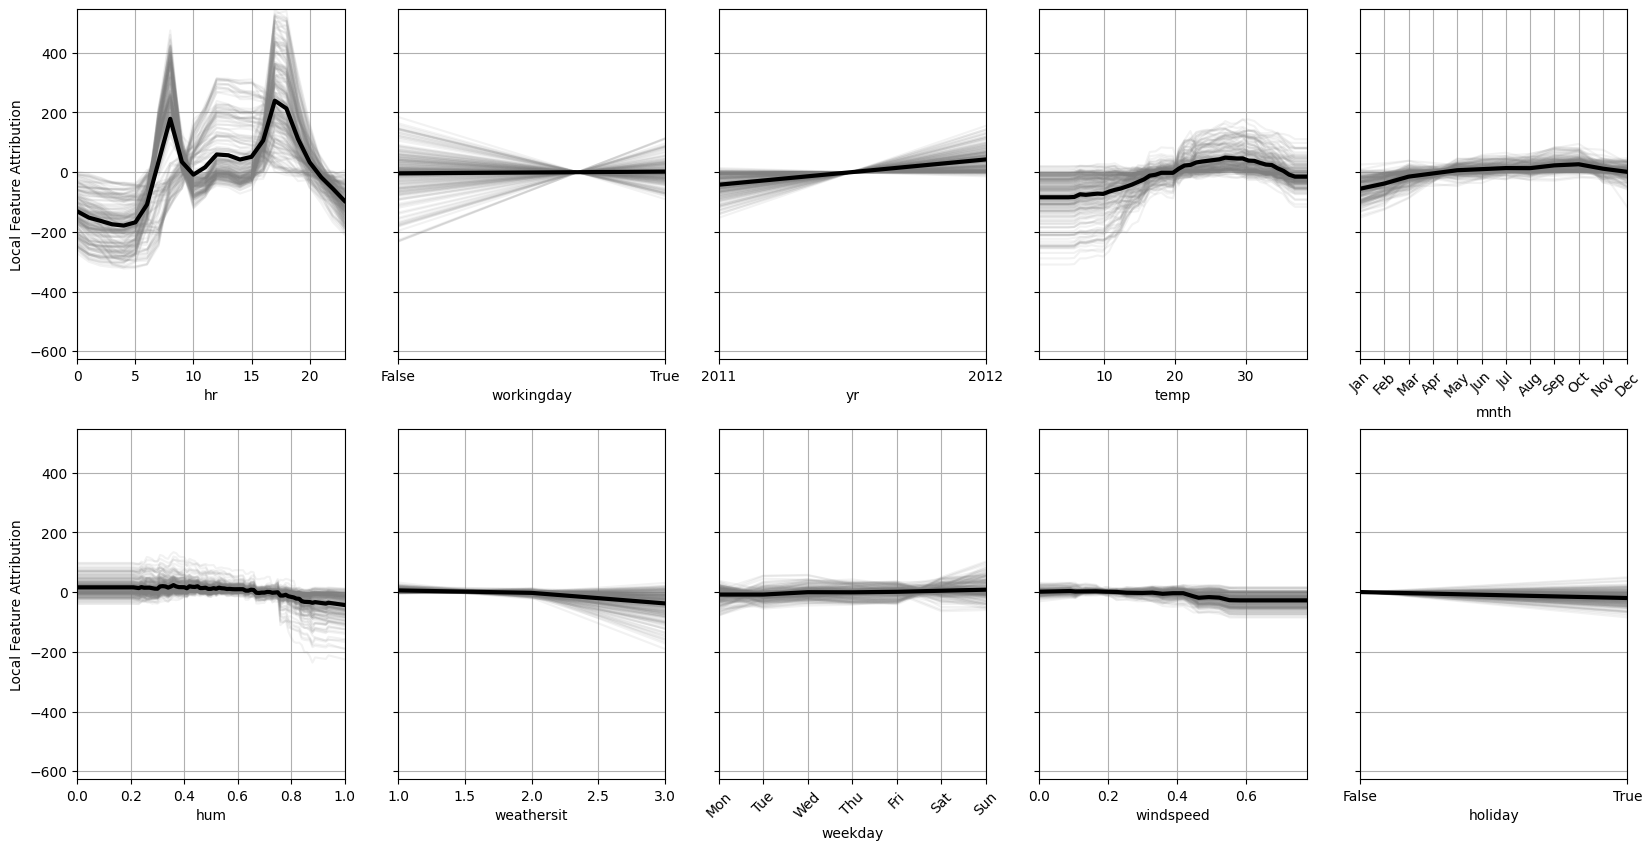

In [40]:
# We plot the h_i terms along side the Shapley Values
partial_dependence_plot(decomposition, background, features, centered=True, figsize=(20, 10))

In this plot, the dark line is the PDP while the thin lines are the ICEs. Difference between the two are indicators of feature interactions. The strongest interactions seem to be involving `hr`, `workingday`, `yr`, and `temp`. 
This means that the effects of changing these features depends on the value of other features. Our local explanations should account for these interactions.

In [41]:
# We minimize the pure-full disagreements of each feature
#U = [(i,) for i in range(len(features))]
U = [(2,)]
# We can split along any feature
features_to_split_upon = [i for i in range(len(features)) if i != 2]
tree = MinimizeSuperset(max_depth=2, features=features.select(features_to_split_upon), alpha=0.07, branching_per_node=1)
tree.fit(background[:, features_to_split_upon], decomposition, U=U)
tree.print(verbose=True)

Loss 0.5885
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.0834
|   Samples 328
|   Region 0
else:
|   Loss 0.1991
|   Samples 672
|   If temp ≤ 19.6800:
|   |   Loss 0.0431
|   |   Samples 291
|   |   Region 1
|   else:
|   |   Loss 0.0741
|   |   Samples 381
|   |   Region 2
Final Loss 0.2006


In [42]:
# Using regional backgrounds
larger_background = X[:4000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2], dtype=int32), array([1254, 1261, 1485]))
{0: 'not workingday', 1: '(workingday & temp<=19.68)', 2: '(workingday & temp>19.68)'}


In [43]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(
        model,
        regional_backgrounds[r],
        regional_backgrounds[r],
        features,
        anchored=True
    )

[##################################################] 100%[                                                  ] 0%

##################################################] 100%[                                                  ] 0%

##############################################    ] 93%

####] 100%

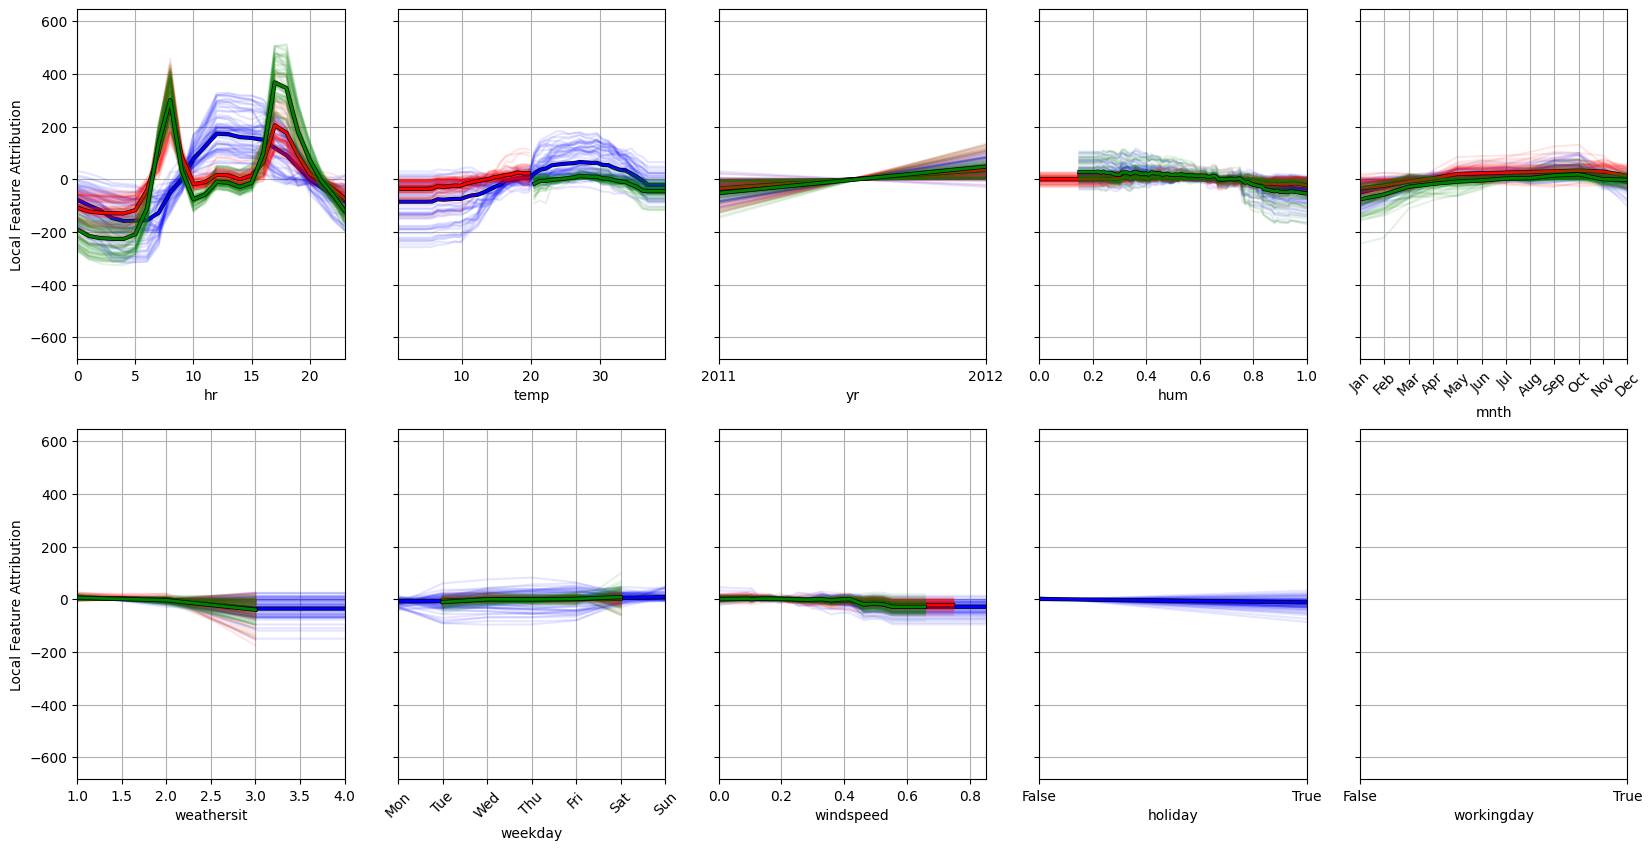

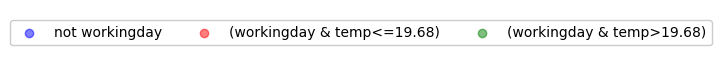

In [44]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(20, 10))
plot_legend(rules, ncol=4)

## Explain with shapiq
Now that we have identified the regions and computed the regional decompositions, we can use shapiq to explain the model's predictions in each region and the whole dataset. We will explain with the 2nd order Shapley interactions (2-SII). We will create two sets of explanations:

1. **Collection of Local Explanations**: For each region and the whole dataset we will create a collection of local explanations which can be summarized in multiple ways (plot with visualizations for multiple instances (global plots) or aggregated further into global summaries.
2. **Global Risk Game**: For each region and the whole dataset, we will use the `GlobalRiskGame` which models a global value function comparing the loss of a model on original and perturbed data.

In [45]:
# setup what you want to explain
from shapiq import InteractionValues

index = "k-SII"
order = 2

rules[-1] = "Whole Data"

First, we will collect the regional datasets from GRANITE. This will then be used for the two shapiq explanation approaches.

In [46]:
# prepare and collect the data for shapiq
n_features = len(features)
regions = tree.predict(X_test[:, features_to_split_upon])
n_samples_local = 100

x_explain_regions: dict[int, np.ndarray] = {}
data_regions: dict[int, np.ndarray] = {}
y_regions: dict[int, np.ndarray] = {}
for r in range(tree.n_regions):
    data_region = X_test[regions==r]
    y_region = y_test[regions==r]
    x_explain_regions[r] = data_region[:n_samples_local].copy()
    data_regions[r] = data_region.copy()
    y_regions[r] = y_region.copy()
    print(f"Region {r} {rules[r]} n_samples: {len(data_region)} y_regions: {len(y_region)}")

# concatenate via rows
data_global = np.concatenate([data_regions[r] for r in data_regions], axis=0)
y_global = np.concatenate([y_regions[r] for r in y_regions], axis=0)
x_explain_global = np.concatenate([x_explain_regions[r] for r in x_explain_regions], axis=0)
print(f"Global n_samples: {len(data_global)}")
x_explain_regions[-1] = x_explain_global
data_regions[-1] = data_global
y_regions[-1] = y_global

Region 0 not workingday n_samples: 1121 y_regions: 1121
Region 1 (workingday & temp<=19.68) n_samples: 1043 y_regions: 1043
Region 2 (workingday & temp>19.68) n_samples: 1312 y_regions: 1312
Global n_samples: 3476


### Local Explanations in the regions
First, we create multiple local explanations of the model in the different regions and on the global set.

In [15]:
from shapiq import TabularExplainer

ivs_local: dict[int, list[InteractionValues]] = {}

# do the local explanations in the region
for r in rules:
    print(f"Region {r} - {len(data_regions[r])} background samples - rule: {rules[r]}")
    explainer = TabularExplainer(
        model,
        data=data_regions[r],
        index=index,
        max_order=order,
    )
    ivs_region = explainer.explain_X(
        X=x_explain_regions[r], budget=2**n_features, verbose=True
    )
    ivs_local[r] = ivs_region

Region 0 - 396 background samples - rule: (not workingday & hr<=7.00)


Explaining: 100%|██████████| 100/100 [02:09<00:00,  1.29s/it]


Region 1 - 725 background samples - rule: (not workingday & hr>7.00)


Explaining: 100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


Region 2 - 690 background samples - rule: (workingday & hr<=6.00)


Explaining: 100%|██████████| 100/100 [02:09<00:00,  1.29s/it]


Region 3 - 1665 background samples - rule: (workingday & hr>6.00)


Explaining: 100%|██████████| 100/100 [02:14<00:00,  1.34s/it]


Region -1 - 3476 background samples - rule: Whole Data


Explaining: 100%|██████████| 400/400 [08:47<00:00,  1.32s/it]


### Global Risk Game with shapiq

In [47]:
from shapiq import AgnosticExplainer

from granite.shapiq_games import GlobalRiskGame
from sklearn.metrics import mean_absolute_error

ivs_global: dict[int, list[InteractionValues]] = {}

# explain in the regions and the whole data
for r in rules:
    print(f"Region {r} - {len(data_regions[r])} background samples - rule: {rules[r]}")
    # do the explanations in the region
    game = GlobalRiskGame(
        data=data_regions[r],
        y_true=y_regions[r],
        model=model.predict,
        loss_function=mean_absolute_error,
        sampling_rounds=4
    )
    explainer = AgnosticExplainer(
        game=game,
        index=index,
        max_order=order,
    )
    explainer.game.verbose = True
    iv_region = explainer.explain(budget=2**n_features)
    print(iv_region)
    ivs_global[r] = iv_region

Region 0 - 1121 background samples - rule: not workingday


Evaluating game: 100%|██████████| 1024/1024 [00:38<00:00, 26.89 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (1, 7): 5.425865891239397
        (2, 8): 4.682540358330638
        (0,): -3.9444875424484134
        (1,): -4.370020041392507
        (8,): -5.479870403803163
        (1, 2): -6.153849660019418
        (0, 2): -7.873689156038599
        (2, 7): -14.656233848073464
        (7,): -21.632810573074593
        (2,): -73.74742000583835
)
Region 1 - 1043 background samples - rule: (workingday & temp<=19.68)


Evaluating game: 100%|██████████| 1024/1024 [00:37<00:00, 27.24 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (9,): 3.6429378137071096
        (6,): 2.8282885404782476
        (5,): 2.2276706286564454
        (7,): -2.31898452552898
        (2, 7): -4.047072905748148
        (0, 1): -4.067706381578909
        (2, 6): -4.882816598319772
        (1, 2): -9.11545993653855
        (0, 2): -13.259288511939411
        (2,): -67.86697930290175
)
Region 2 - 1312 background samples - rule: (workingday & temp>19.68)


Evaluating game: 100%|██████████| 1024/1024 [00:36<00:00, 28.33 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (3,): -2.1813505158948114
        (5,): -2.1813544849584305
        (1, 2): -3.0070161243256996
        (2, 7): -3.429312804074662
        (6,): -3.7581823411452886
        (2, 4): -4.284010353569485
        (0,): -6.197259905637349
        (8,): -9.399234010093226
        (0, 2): -27.875923999687895
        (2,): -127.73253821502296
)
Region -1 - 3476 background samples - rule: Whole Data


Evaluating game: 100%|██████████| 1024/1024 [00:44<00:00, 23.19 coalition/s]

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (0,): -4.403326712397888
        (1, 2): -4.730582870535422
        (1,): -5.1860131187460485
        (2, 4): -5.525704403442724
        (8,): -7.538310413205627
        (2, 7): -9.575311069021938
        (7,): -12.219736149715981
        (0, 2): -12.697963411742986
        (2, 5): -20.275020075664415
        (2,): -72.70560075428875
)


In [49]:
# find the min and max values of all global ivs
min_iv = np.inf
max_iv = -np.inf
for r, ivs in ivs_global.items():
    min_iv = min(np.min(ivs), min_iv)
    max_iv = max(np.max(ivs), max_iv)
print(min_iv, max_iv)

-127.73253821502296 5.425865891239397


## Visualizations in shapiq
Here follows a collection of visualizations that can be used from shapiq. Global plots can visualize multiple explanations at once (approach 1). The other visualizations can only be used to visualize a single explanation, which is helpful to visualize a global explanation (approach 2).

### Bar Plot (global plot)
We can visualize a global explanation as a bar plot. The bars represent the absolute value of the interaction values, which indicate the importance of each feature in the model's prediction for that region.

In [15]:
from shapiq import bar_plot

for r, ivs_region in ivs_local.items():
    display(f"Region {r} - rule: {rules[r]}")
    ax = bar_plot(ivs_region, show=False, feature_names=features.names(), max_display=10)
    ax.set_xlim(0, 200)
    plt.show()

NameError: name 'ivs_local' is not defined

### Beesvarm plot (global plot)
The beeswarm plot provides a more detailed view of the interaction values, showing the distribution of interaction values for each feature across the samples in the region. Each point represents an interaction value for a sample, and the color indicates the feature.

'Region 0 - rule: (not workingday & hr<=7.00)'

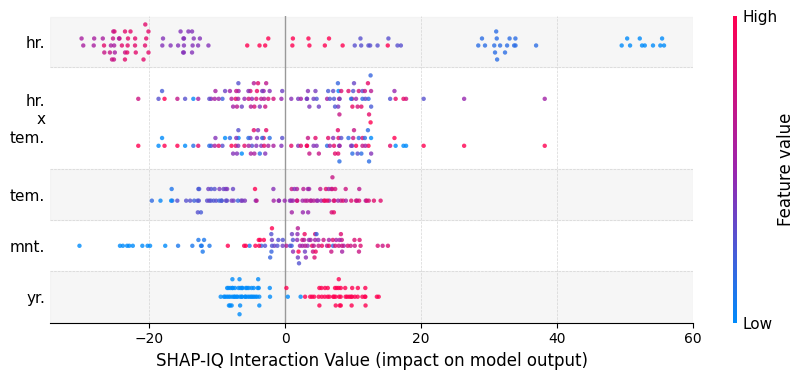

'Region 1 - rule: (not workingday & hr>7.00)'

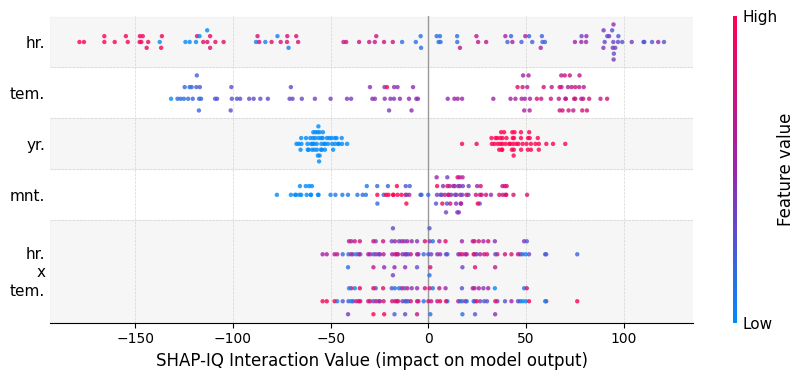

'Region 2 - rule: (workingday & hr<=6.00)'

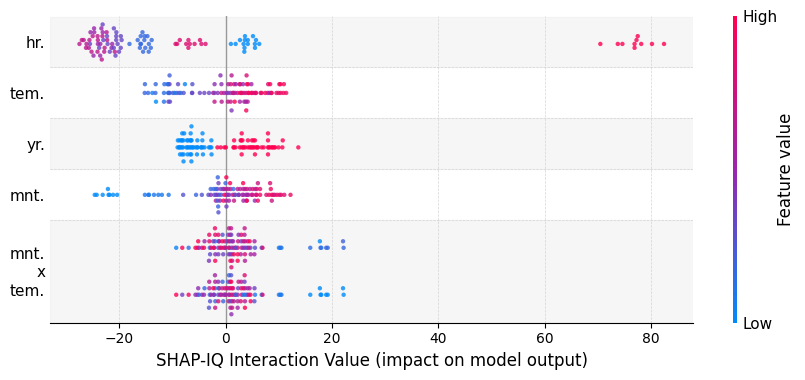

'Region 3 - rule: (workingday & hr>6.00)'

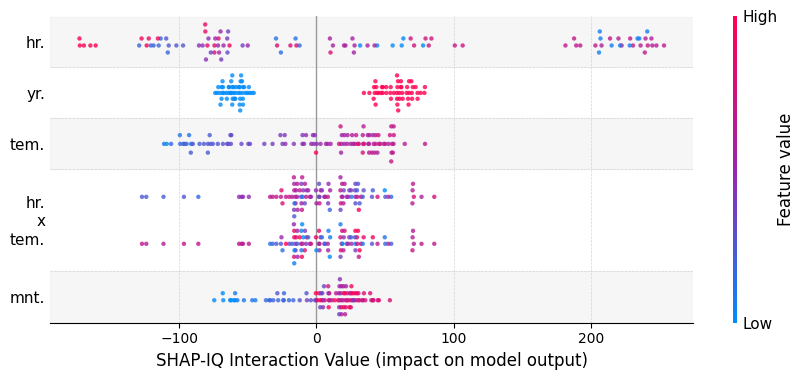

'Region -1 - rule: Whole Data'

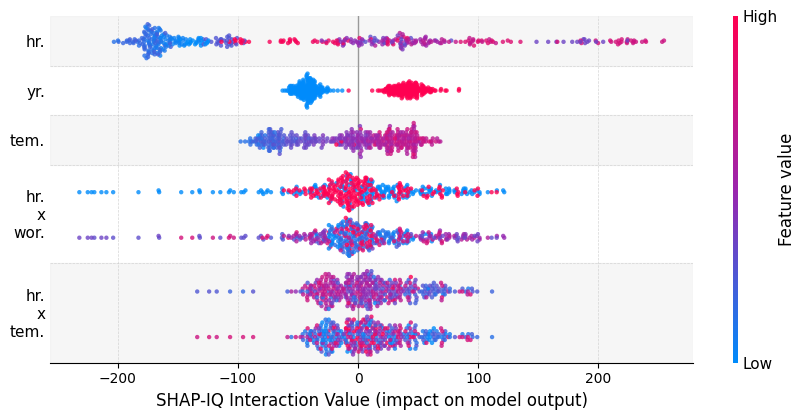

In [28]:
from shapiq import beeswarm_plot

for r, ivs_region in ivs_local.items():
    display(f"Region {r} - rule: {rules[r]}")
    x_explain = x_explain_regions[r]
    beeswarm_plot(ivs_region, data=x_explain, show=True, feature_names=features.names(), max_display=5)

### Stacked Bar Plot (local plot)
The stacked bar plot shows for each interaction order the sum of interaction scores in the positive and negative directions.

'Region 0 - rule: (not workingday & hr<=7.00)'

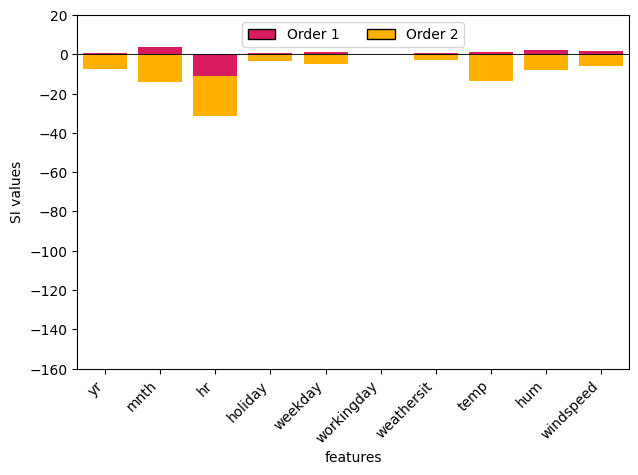

'Region 1 - rule: (not workingday & hr>7.00)'

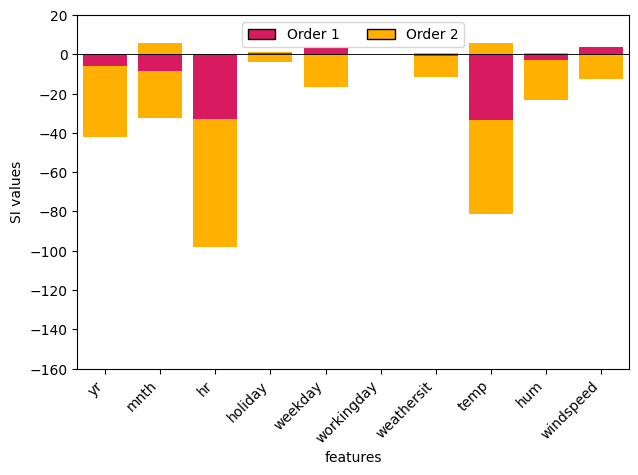

'Region 2 - rule: (workingday & hr<=6.00)'

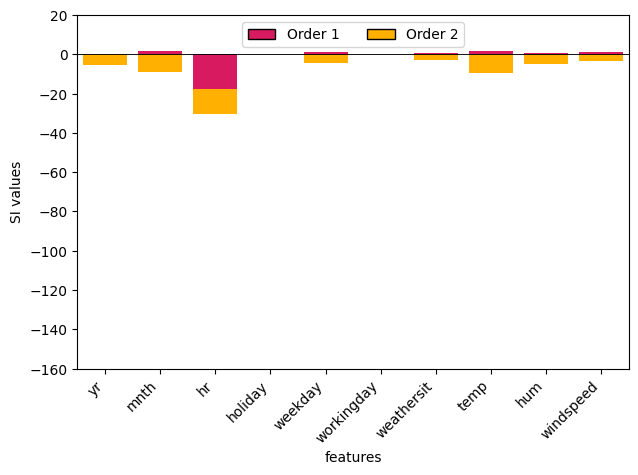

'Region 3 - rule: (workingday & hr>6.00)'

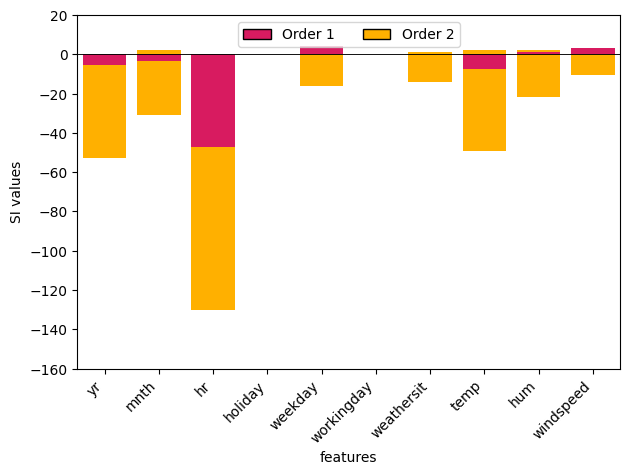

'Region -1 - rule: Whole Data'

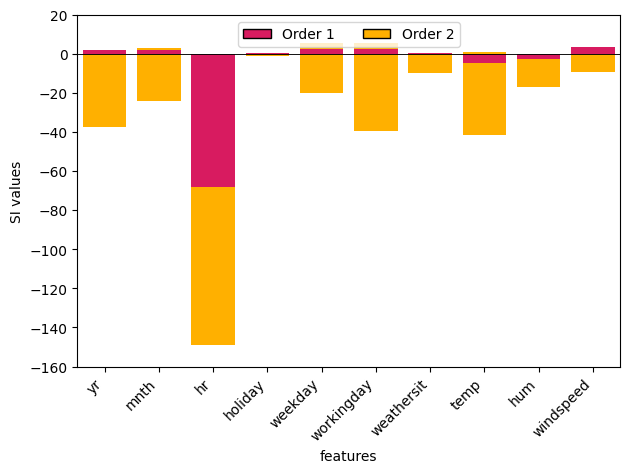

In [16]:
from shapiq import stacked_bar_plot

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    _, ax = stacked_bar_plot(ivs_region, show=False, feature_names=features.names())
    ax.set_ylim(-160, 20)
    plt.show()

### SI-Graph (local plot)
The SI-Graph is a local visualization that shows the interaction values for a specific sample. It plots the interactions as a hypergraph, where edges represent interaction strengths between features and nodes represents main effects.

'Region 0 - rule: not workingday'

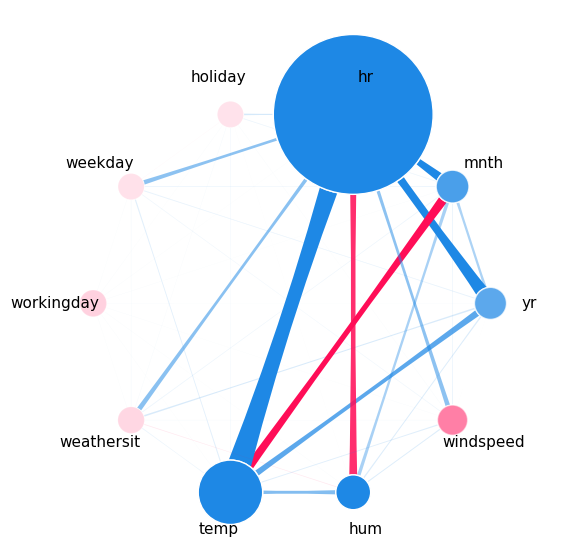

'Region 1 - rule: (workingday & temp<=19.68)'

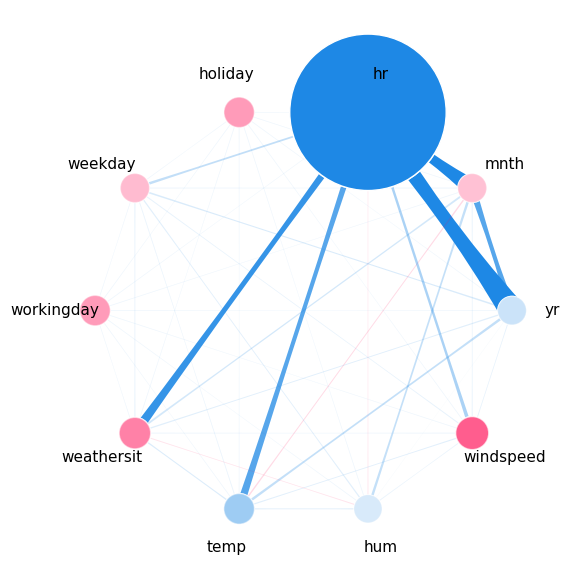

'Region 2 - rule: (workingday & temp>19.68)'

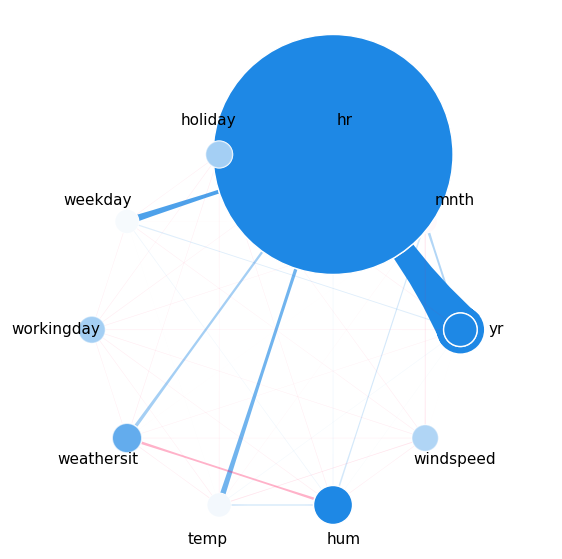

'Region -1 - rule: Whole Data'

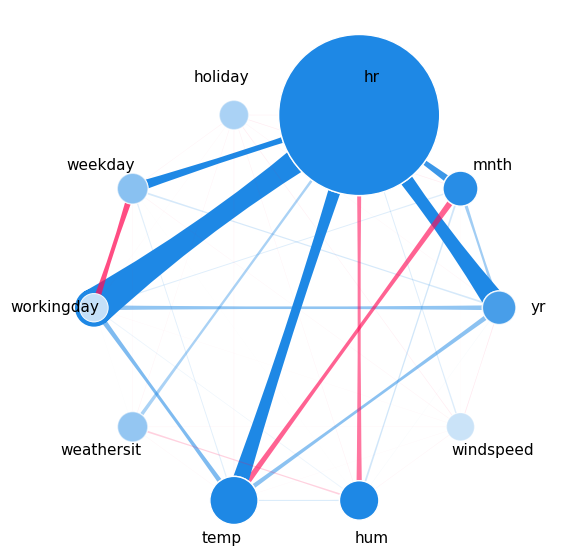

In [50]:
from shapiq import si_graph_plot

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    si_graph_plot(ivs_region, show=True, feature_names=features.names(), min_max_interactions=(min_iv, max_iv))

### Force Plot (local plot)
The force plot visualizes the contribution of each feature to the model's prediction for a specific sample. It shows how each feature pushes the prediction up or down from the baseline.

'Region 0 - rule: (not workingday & hr<=7.00)'

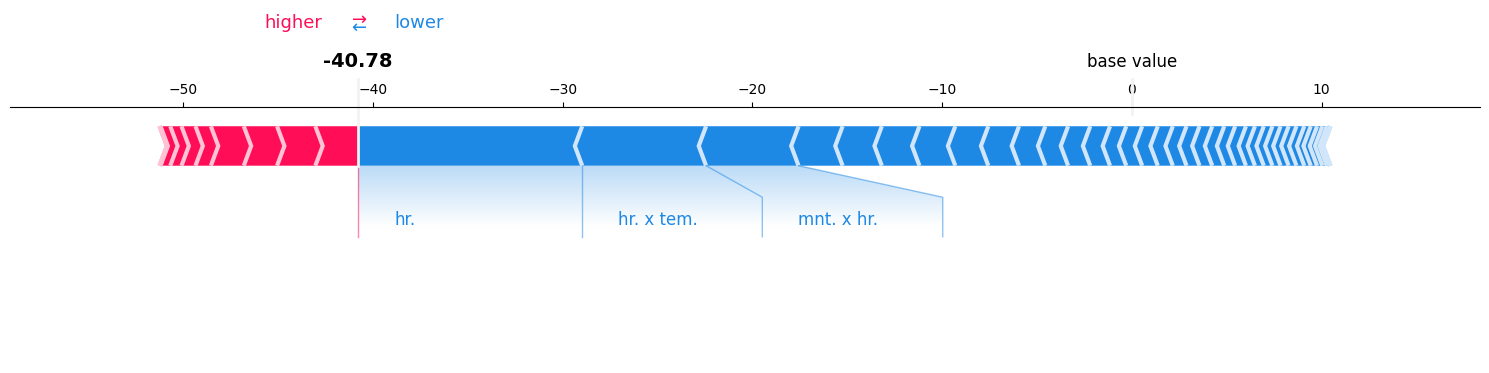

'Region 1 - rule: (not workingday & hr>7.00)'

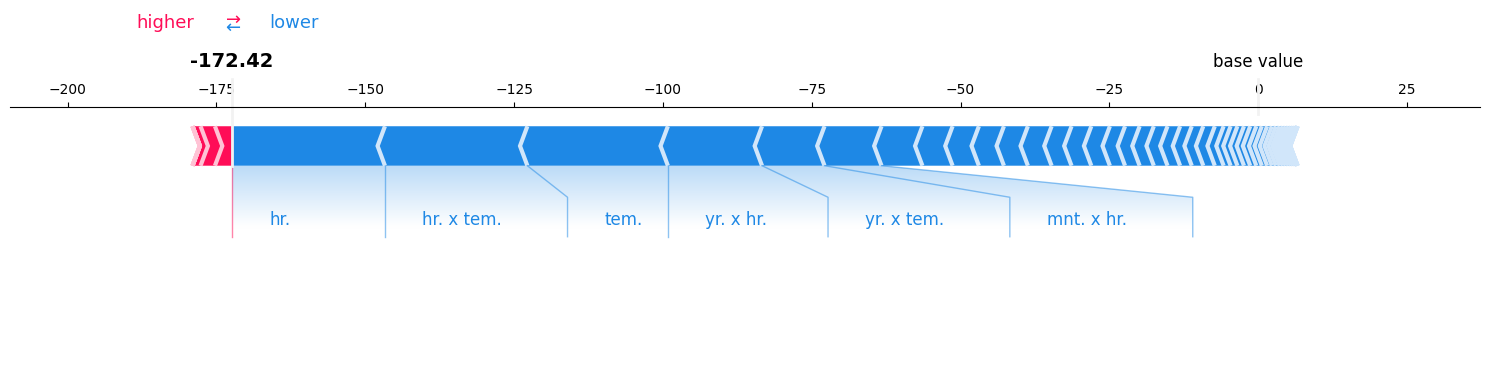

'Region 2 - rule: (workingday & hr<=6.00)'

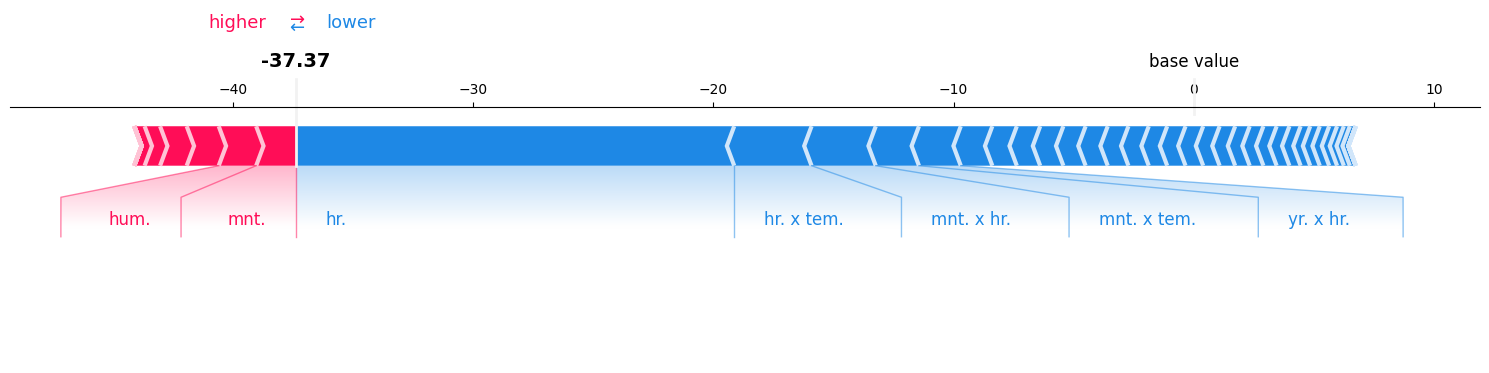

'Region 3 - rule: (workingday & hr>6.00)'

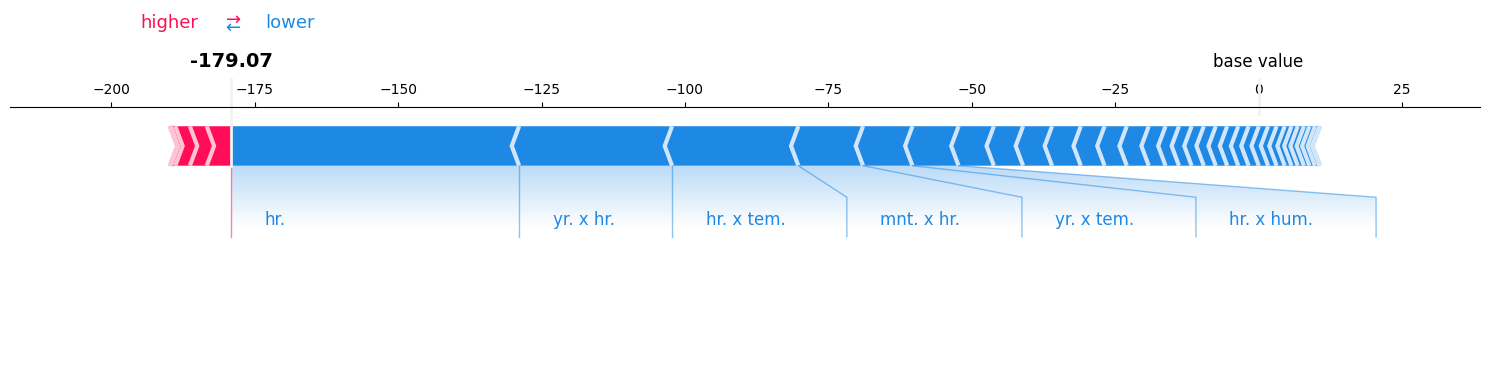

'Region -1 - rule: Whole Data'

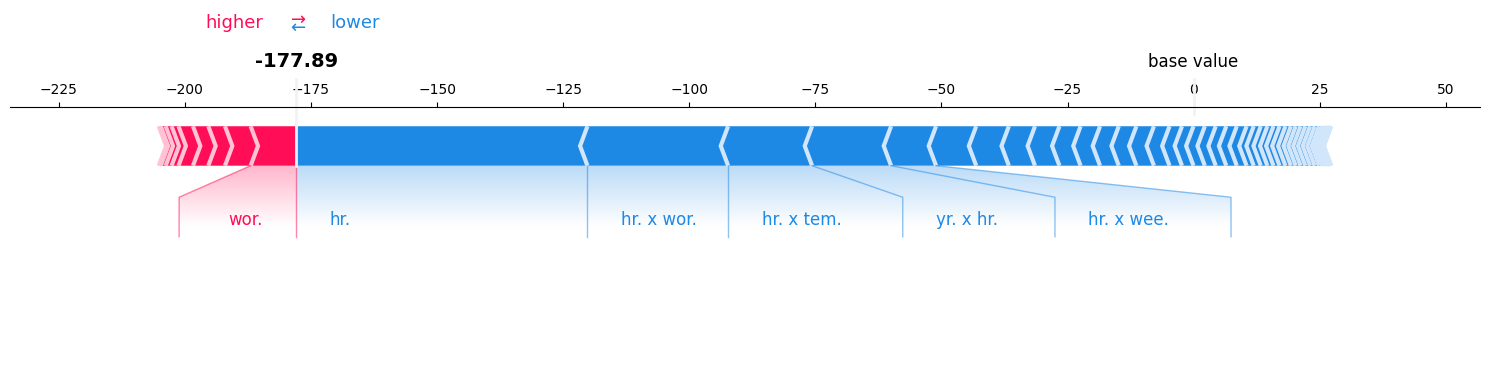

In [36]:
from shapiq import force_plot

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    force_plot(ivs_region, show=True, feature_names=features.names())

### Waterfall Plot (local plot)
The waterfall plot is another version of the force plot, which displays the contributions of each feature in a stacked manner.

'Region 0 - rule: (not workingday & hr<=7.00)'

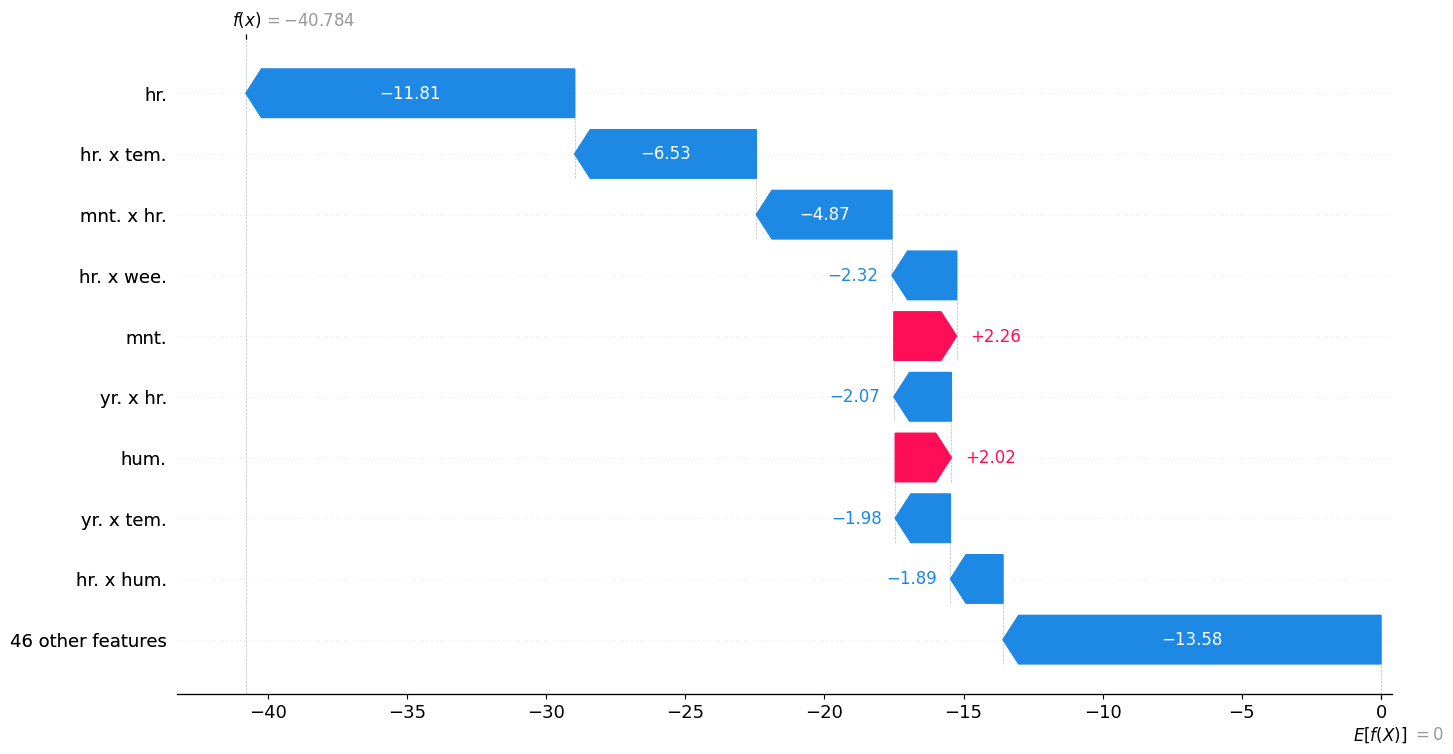

'Region 1 - rule: (not workingday & hr>7.00)'

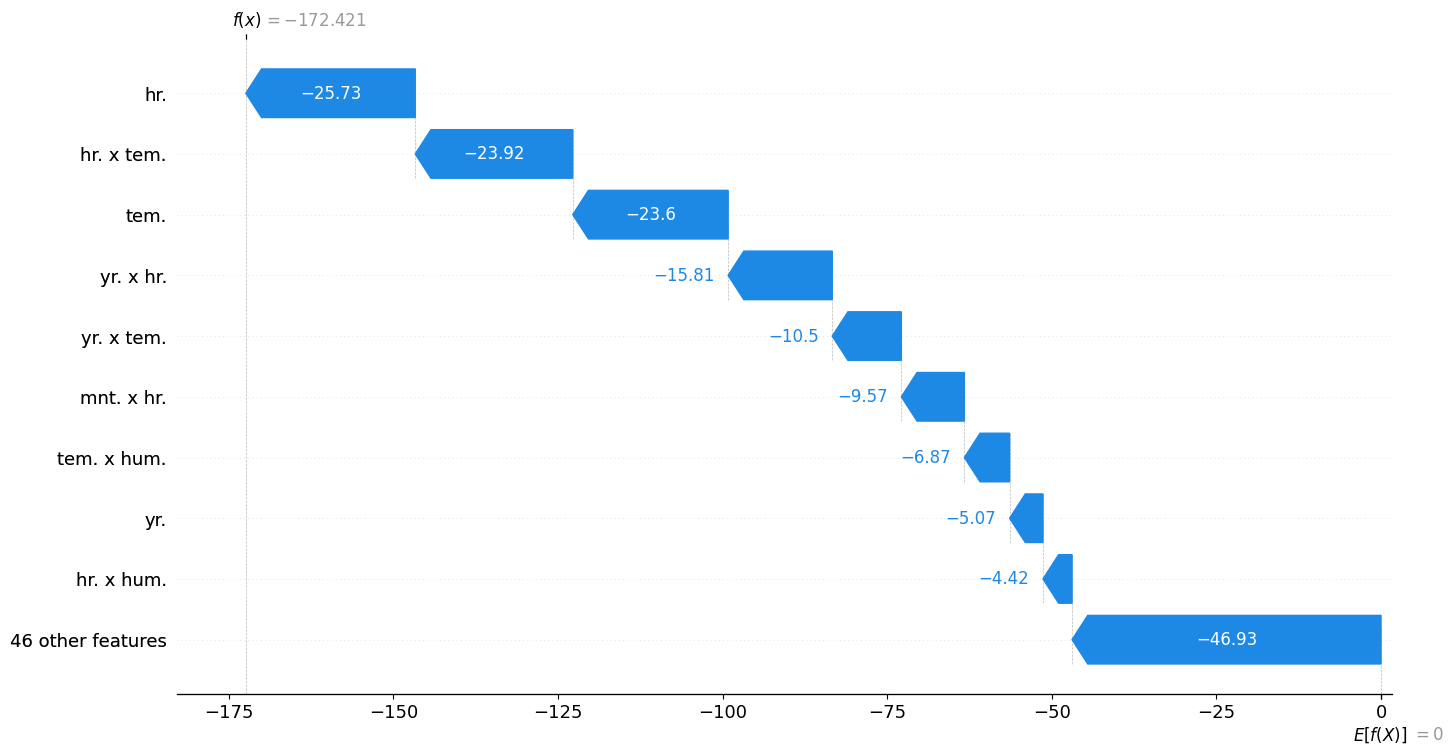

'Region 2 - rule: (workingday & hr<=6.00)'

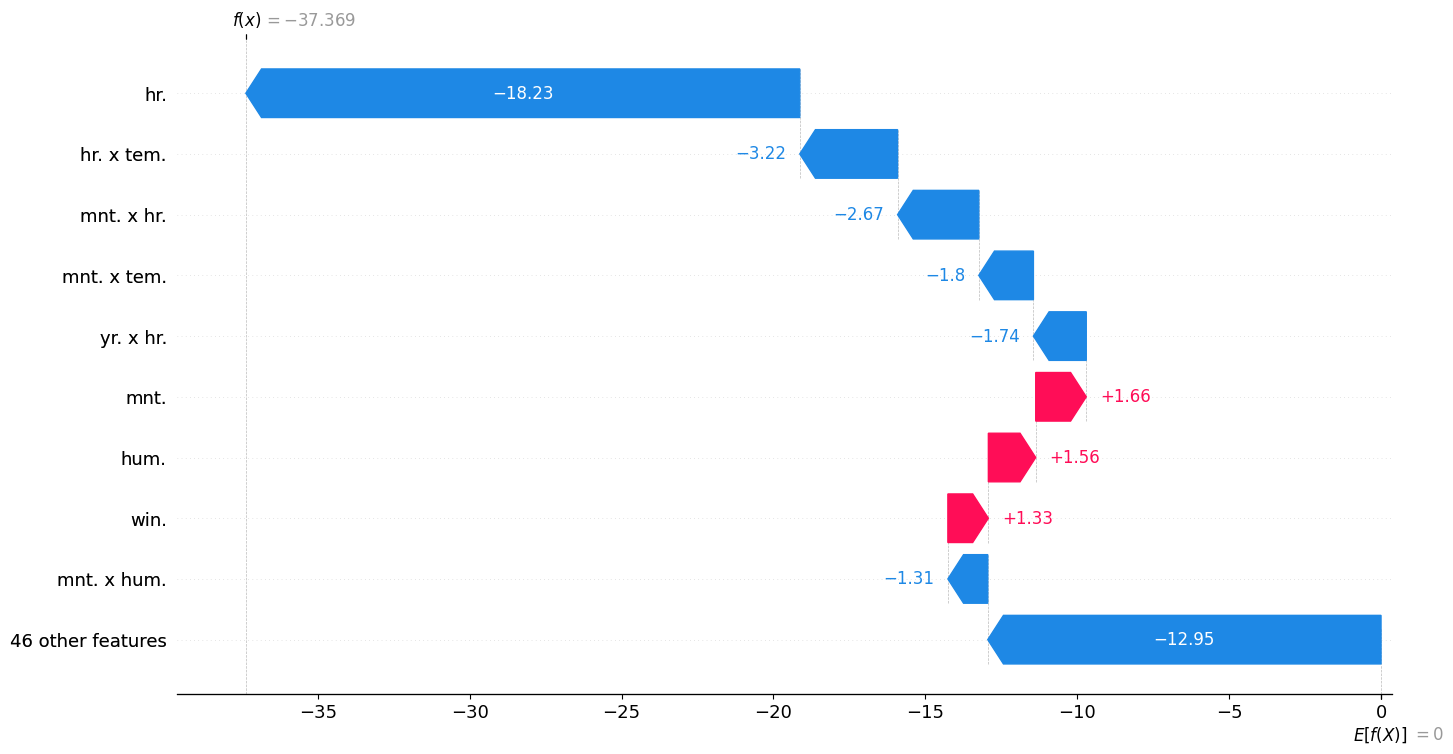

'Region 3 - rule: (workingday & hr>6.00)'

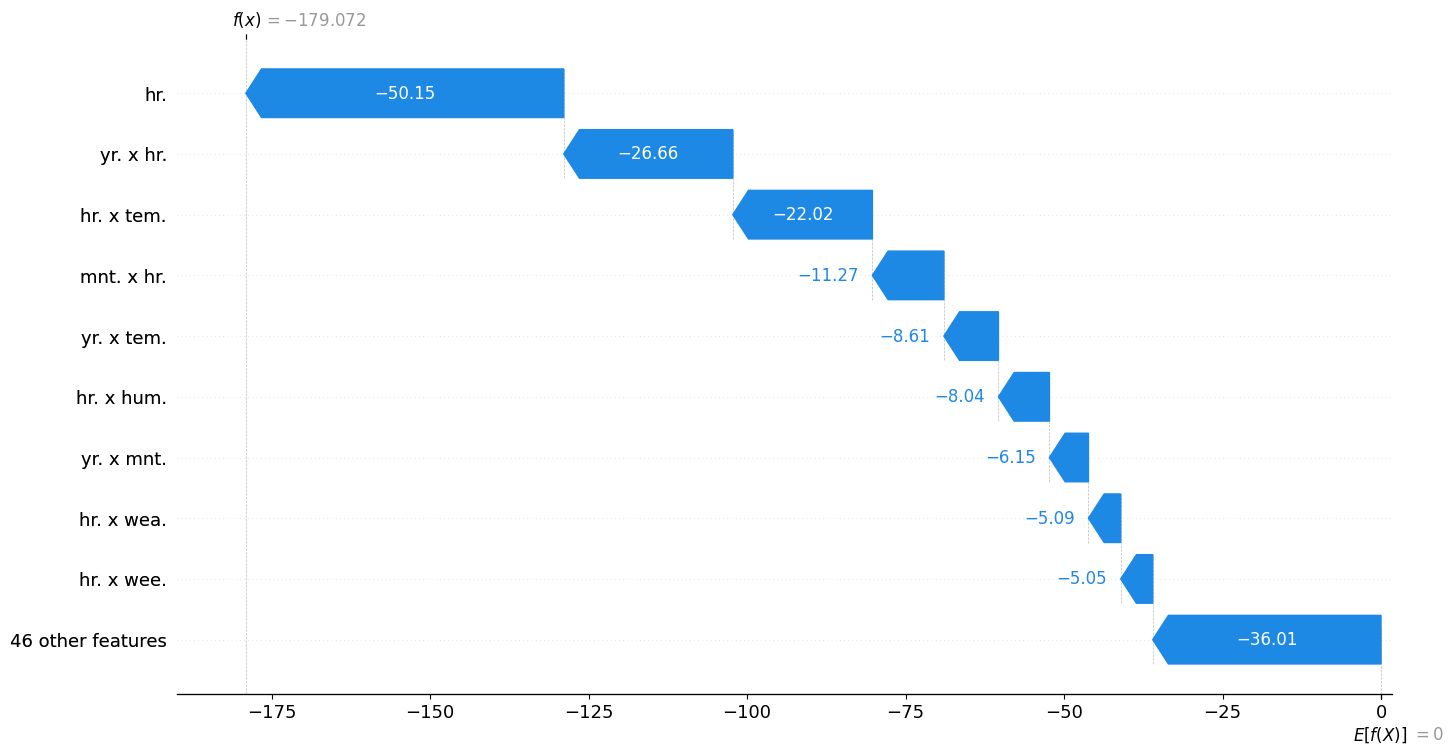

'Region -1 - rule: Whole Data'

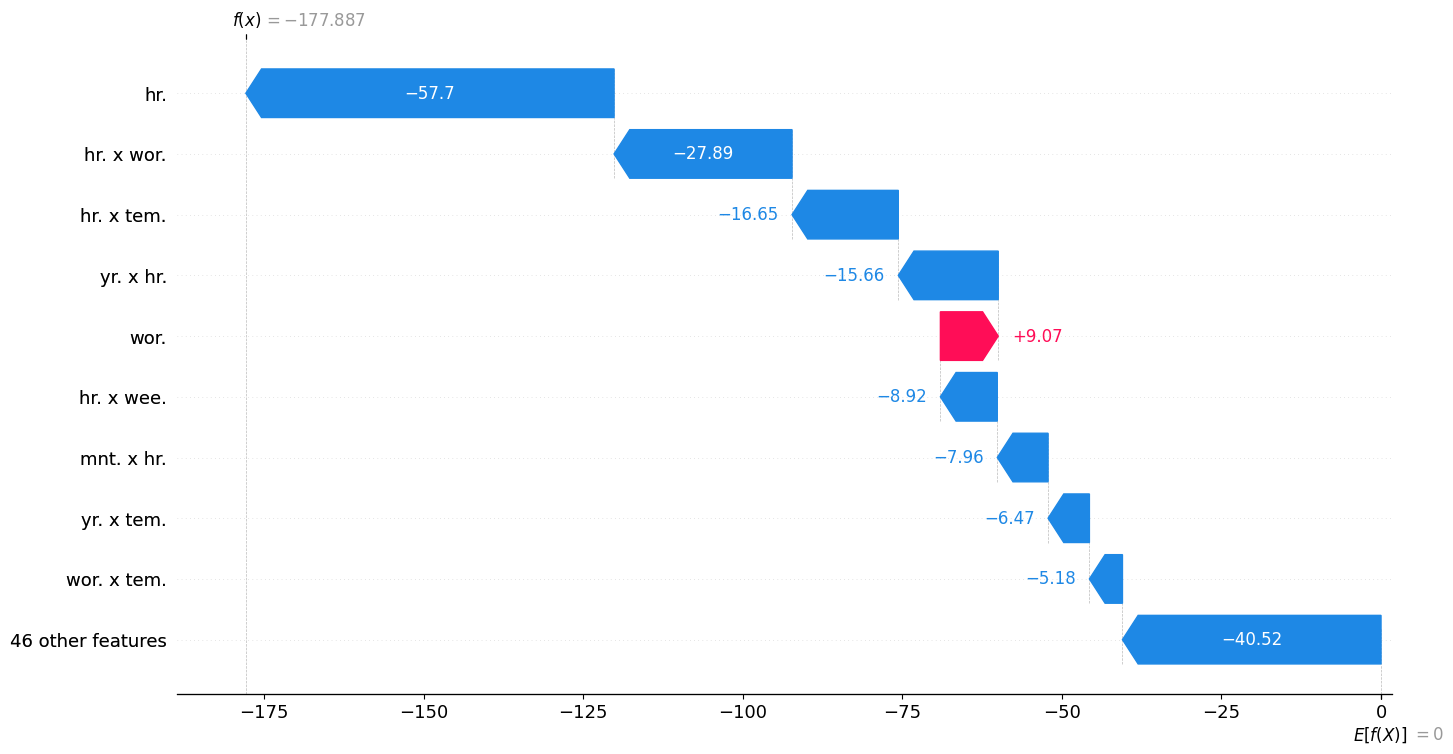

In [37]:
from shapiq import waterfall_plot

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    waterfall_plot(ivs_region, show=True, feature_names=features.names())

### UpSet Plot (local plot)
The UpSet plot visualizes the interactions scores as vertical bars and adds a matrix that shows which features are involved in each interaction. The UpSet plot is quite well-known visualization for sets.

'Region 0 - rule: (not workingday & hr<=7.00)'

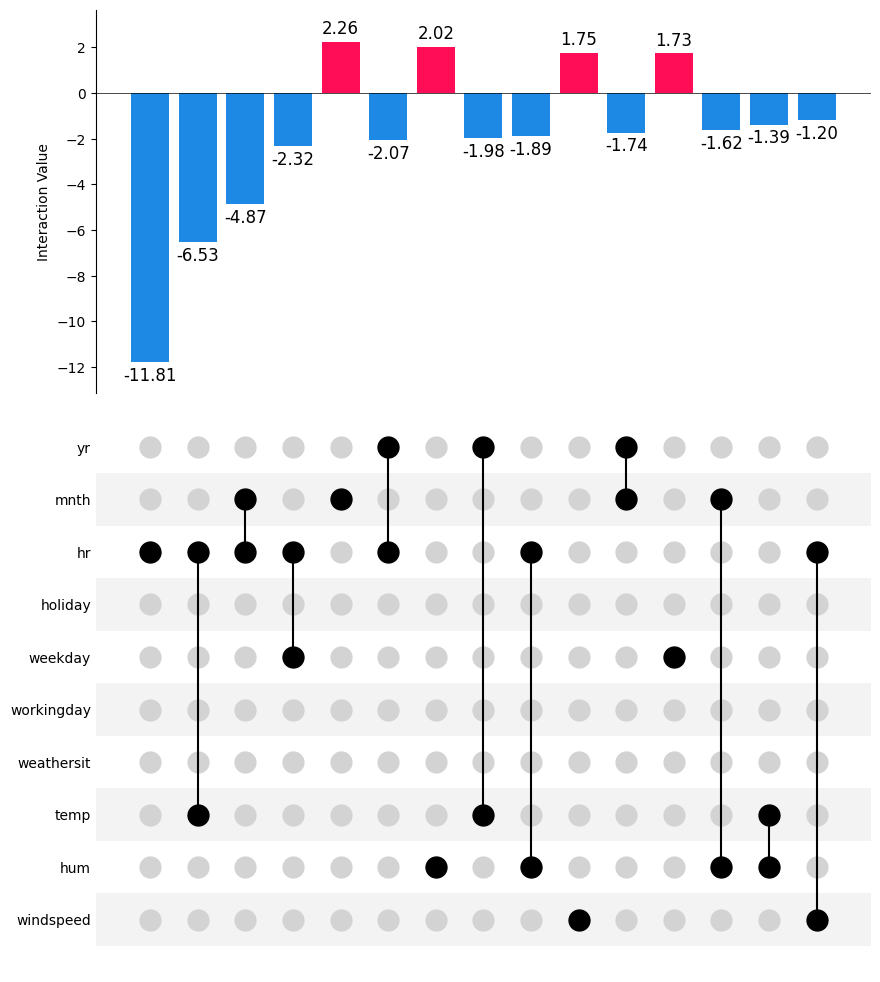

'Region 1 - rule: (not workingday & hr>7.00)'

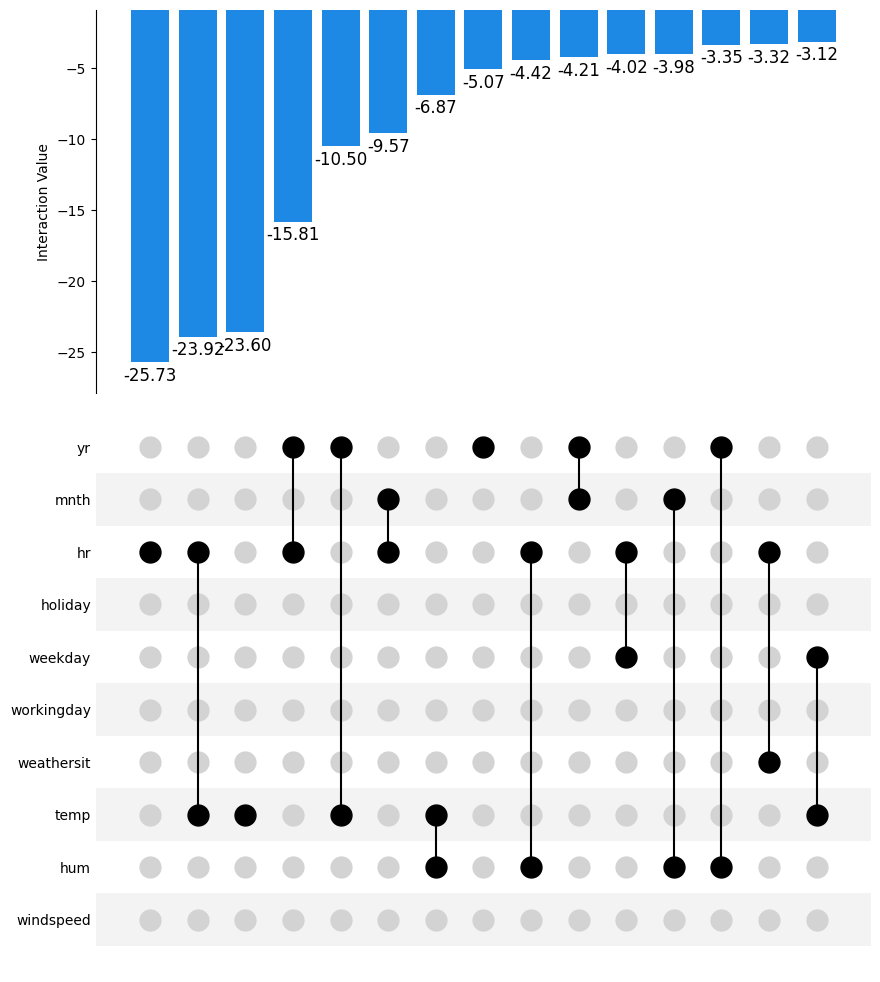

'Region 2 - rule: (workingday & hr<=6.00)'

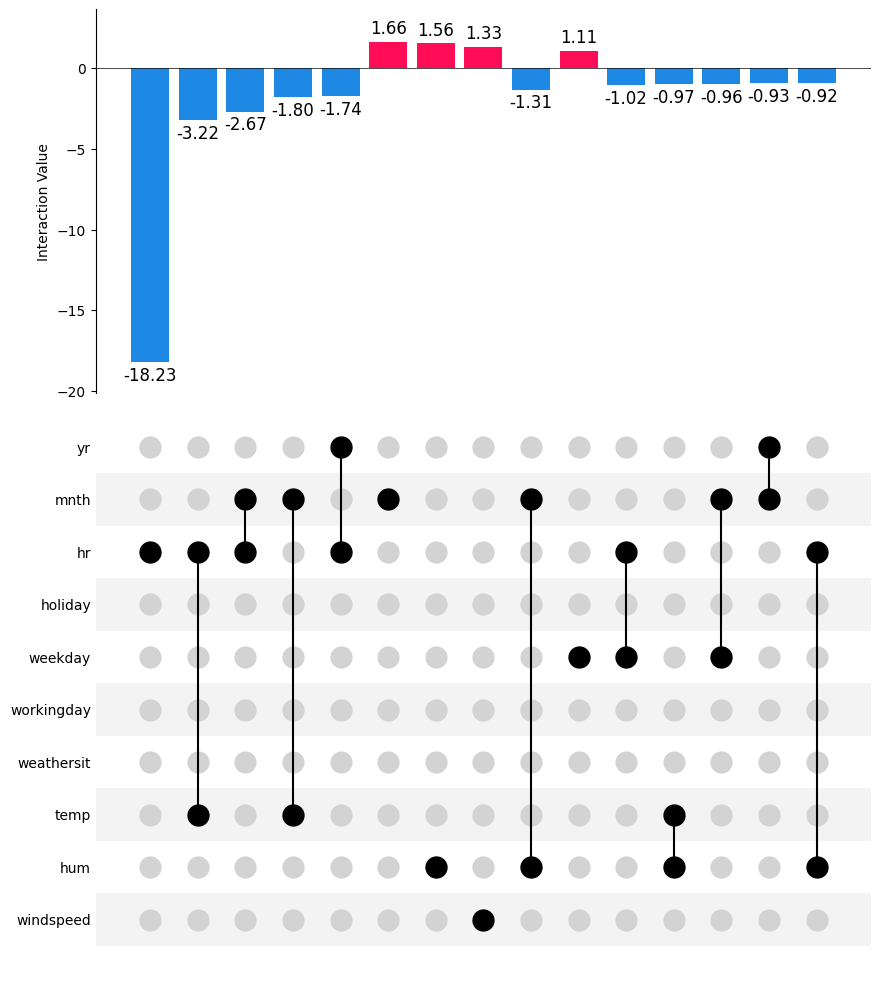

'Region 3 - rule: (workingday & hr>6.00)'

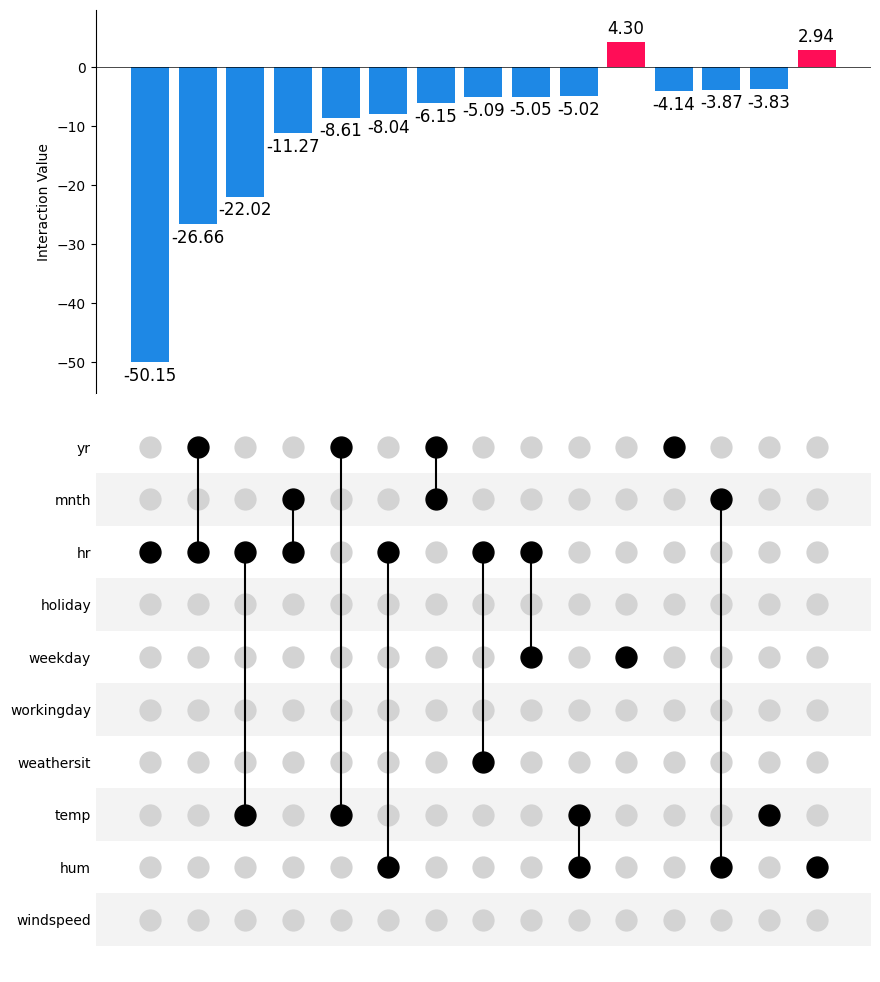

'Region -1 - rule: Whole Data'

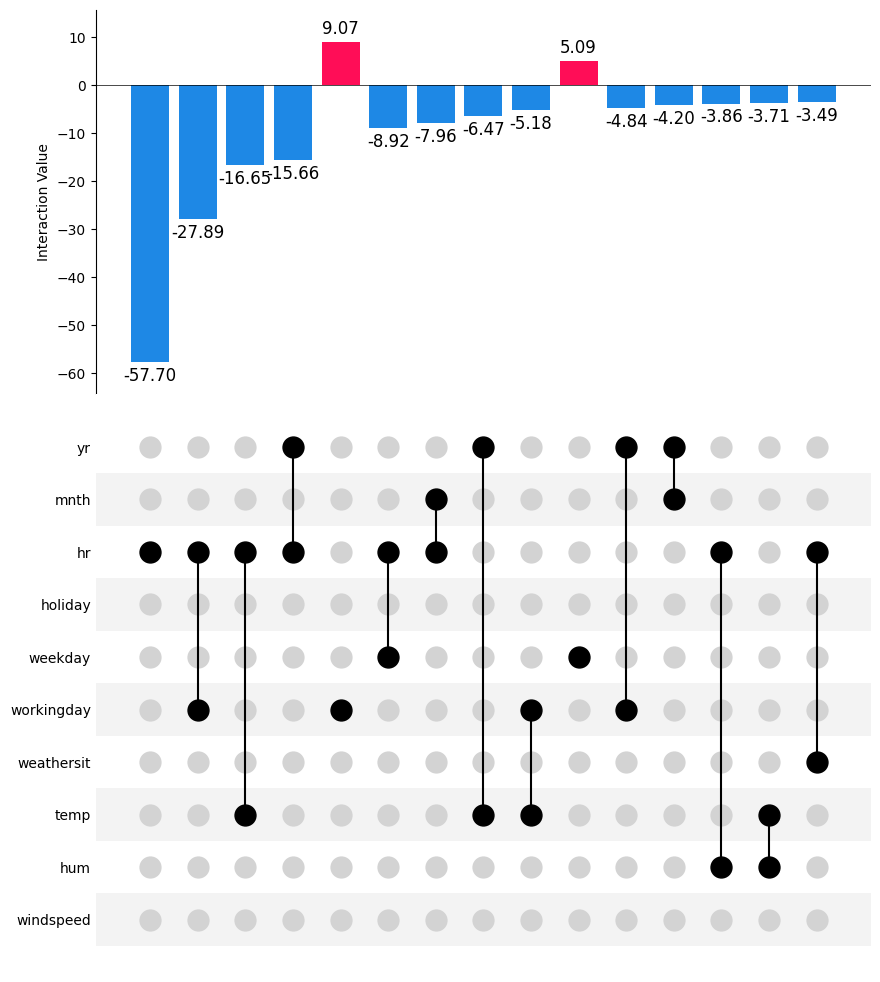

In [38]:
from shapiq import upset_plot

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    upset_plot(ivs_region, show=True, feature_names=features.names(), n_interactions=15)